In [1]:
import json
import requests
import pandas as pd

# https://min-api.cryptocompare.com/data/histoday?fsym=KUB&tsym=USD&limit=2000
endpoint = "https://min-api.cryptocompare.com/data/histoday"
url = endpoint + "?fsym=KUB&tsym=USD&limit=2000"
res = requests.get(url, timeout=30)
res.raise_for_status()
 
data = json.loads(res.content)["Data"]
hist = pd.DataFrame(data)
hist = hist.set_index("time")
hist.index = pd.to_datetime(hist.index, unit="s")
 
target_col = "close"
series = hist[[target_col]].copy().dropna()
series = series[series[target_col] > 0].copy()
series = series.sort_index()
 
prices = series[target_col].values  
dates = series.index                

In [2]:
import numpy as np

logret = np.log(prices[1:] / prices[:-1]).astype(np.float32)
ret_dates = dates[1:]

In [3]:
seq_len = 30  

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(logret, seq_len)
seq_dates = ret_dates[seq_len:]  

split_ratio = 0.8
split_idx = int(len(X) * split_ratio)

train_X, train_y = X[:split_idx], y[:split_idx]
test_X, test_y = X[split_idx:], y[split_idx:]
train_dates = seq_dates[:split_idx]
test_dates = seq_dates[split_idx:]

In [4]:
import torch

# แปลงเป็น tensor - X มี shape (n, seq_len, 1), y มี shape (n, 1)
train_X_tensor = torch.from_numpy(train_X).unsqueeze(-1)  # (n, seq_len, 1)
train_y_tensor = torch.from_numpy(train_y).unsqueeze(-1)  # (n, 1)
test_X_tensor = torch.from_numpy(test_X).unsqueeze(-1)    # (m, seq_len, 1)
test_y_tensor = torch.from_numpy(test_y).unsqueeze(-1)    # (m, 1)

print(f"Train X: {train_X_tensor.shape}, Train y: {train_y_tensor.shape}")
print(f"Test X: {test_X_tensor.shape}, Test y: {test_y_tensor.shape}")

Train X: torch.Size([989, 30, 1]), Train y: torch.Size([989, 1])
Test X: torch.Size([248, 30, 1]), Test y: torch.Size([248, 1])


In [5]:
import torch

class LSTMModel(torch.nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = torch.nn.LSTM(input_size = input_size, 
                                  hidden_size=hidden_size, 
                                  num_layers=num_layers,
                                  batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.fc = torch.nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Take the output of the last time step
        return out

In [6]:
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_LSTM = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_LSTM.parameters(), lr=0.001)

Using device: cuda


In [7]:
epochs = 1000
batch_size = 32

model_LSTM.train()
loss_list = []

for epoch in range(epochs):
    permutation = torch.randperm(train_X_tensor.size(0))
    epoch_loss = 0.0
    
    for i in range(0, train_X_tensor.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        batch_x = train_X_tensor[indices].to(device)  # (batch, seq_len, 1)
        batch_y = train_y_tensor[indices].to(device)  # (batch, 1) - ค่าถัดไป
        
        optimizer.zero_grad()
        outputs = model_LSTM(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_x.size(0)
    
    epoch_loss /= train_X_tensor.size(0)
    loss_list.append(epoch_loss)
    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.6f}")

Epoch [1/1000], Loss: 0.002044
Epoch [50/1000], Loss: 0.001325
Epoch [100/1000], Loss: 0.001306
Epoch [150/1000], Loss: 0.001274
Epoch [200/1000], Loss: 0.001205
Epoch [250/1000], Loss: 0.001093
Epoch [300/1000], Loss: 0.000900
Epoch [350/1000], Loss: 0.001165
Epoch [400/1000], Loss: 0.000555
Epoch [450/1000], Loss: 0.000397
Epoch [500/1000], Loss: 0.000180
Epoch [550/1000], Loss: 0.000127
Epoch [600/1000], Loss: 0.000067
Epoch [650/1000], Loss: 0.000070
Epoch [700/1000], Loss: 0.000041
Epoch [750/1000], Loss: 0.000046
Epoch [800/1000], Loss: 0.000259
Epoch [850/1000], Loss: 0.000027
Epoch [900/1000], Loss: 0.000032
Epoch [950/1000], Loss: 0.000026
Epoch [1000/1000], Loss: 0.000022


In [8]:
model_LSTM.eval()

# Predict train set
with torch.no_grad():
    train_pred = model_LSTM(train_X_tensor.to(device)).cpu().squeeze().numpy()

# Predict test set  
with torch.no_grad():
    test_pred = model_LSTM(test_X_tensor.to(device)).cpu().squeeze().numpy()

# Forecast - 2026-06-30
forecast_end = pd.Timestamp("2026-06-30")
last_date = dates[-1]
n_forecast = (forecast_end - last_date).days

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_forecast, freq='D')
future_preds = []

last_seq = torch.tensor(logret[-seq_len:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)

with torch.no_grad():
    for _ in range(n_forecast):
        pred = model_LSTM(last_seq)
        future_preds.append(pred.item())
        new_val = pred.unsqueeze(-1) 
        last_seq = torch.cat([last_seq[:, 1:, :], new_val], dim=1)

future_preds = np.array(future_preds)

train_start_idx = seq_len + 1 
train_end_idx = train_start_idx + len(train_pred)
test_start_idx = train_end_idx
test_end_idx = test_start_idx + len(test_pred)

train_prices = prices[train_start_idx:train_end_idx]
test_prices = prices[test_start_idx:test_end_idx]
train_price_dates = dates[train_start_idx:train_end_idx]
test_price_dates = dates[test_start_idx:test_end_idx]

train_price_pred = prices[train_start_idx - 1 : train_end_idx - 1] * np.exp(train_pred)

test_price_pred = prices[test_start_idx - 1 : test_end_idx - 1] * np.exp(test_pred)

future_prices = [prices[-1]] 
for lr in future_preds:
    future_prices.append(future_prices[-1] * np.exp(lr))
future_prices = np.array(future_prices[1:])

print(f"Train: {len(train_prices)} days, Test: {len(test_prices)} days, Forecast: {len(future_prices)} days")

Train: 989 days, Test: 248 days, Forecast: 147 days


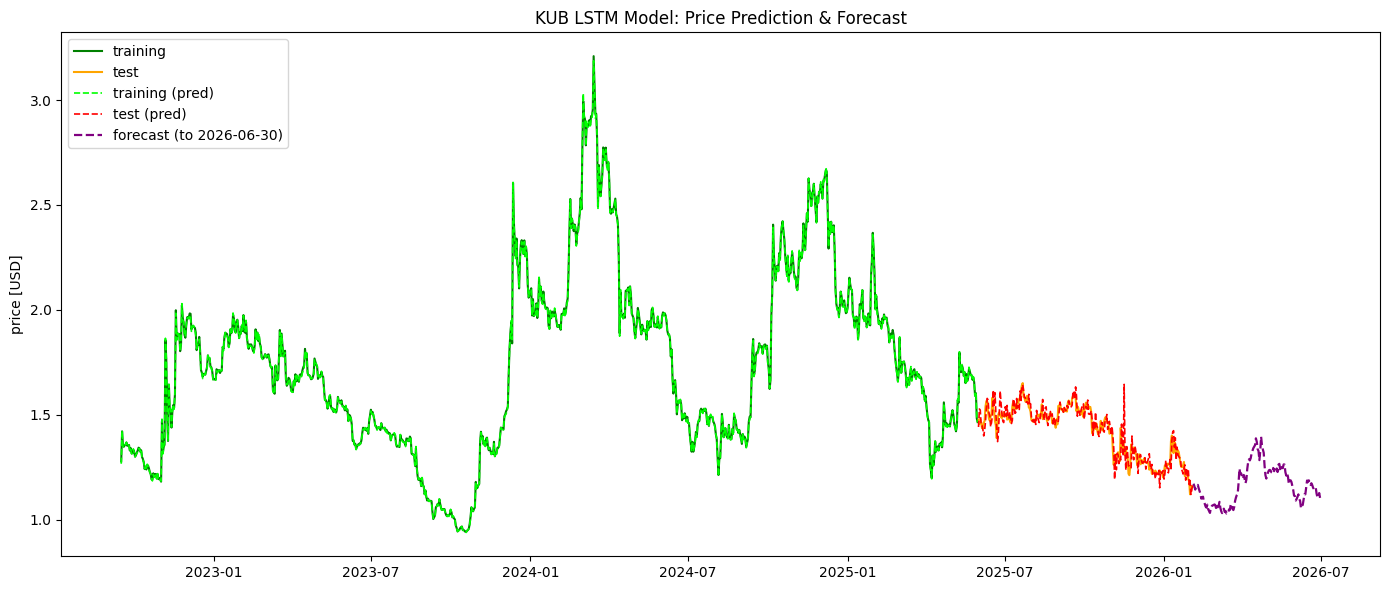

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(train_price_dates, train_prices, label="training", color='green')
plt.plot(test_price_dates, test_prices, label="test", color='orange')

plt.plot(train_price_dates, train_price_pred, linestyle="--", linewidth=1.2, label="training (pred)", color='lime')
plt.plot(test_price_dates, test_price_pred, linestyle="--", linewidth=1.2, label="test (pred)", color='red')

if len(future_dates) > 0:
    plt.plot(future_dates, future_prices, linestyle="--", linewidth=1.6, label=f"forecast (to 2026-06-30)", color='purple')

plt.ylabel("price [USD]")
plt.legend(loc="upper left")
plt.title("KUB LSTM Model: Price Prediction & Forecast")
plt.tight_layout()
plt.show()